In [83]:
!which python

/Users/admin/deaplearning/.venv/bin/python


In [84]:
import copy
import nltk
from nltk import word_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.corpus import wordnet
from nltk.corpus import stopwords

from pymystem3 import Mystem

import pymorphy3

from graph_storage import GraphStorage
from utils import build_and_show_graph

In [85]:
db = GraphStorage(path_to_storage_file='db.json')

In [86]:
# db.index

In [87]:
morph = pymorphy3.MorphAnalyzer()
lemmatizer = WordNetLemmatizer()
sw = stopwords.words('russian')

In [88]:
def tokenize(text):
    tokenized_text = word_tokenize(text, language='russian')
    return [token.lower() for token in tokenized_text if token.lower() not in sw]

In [89]:
# text = "кот моет раму"
# text = "Ребенок держит флаг"
# text = "Мальчик бьет по мячу"
# text = "Мальчик стоит на доске"
text = "Мяч на траве"

In [90]:
tokens = tokenize(text)
tokens

['мяч', 'траве']

In [91]:
def lemmatize(text):
    lemmas = [morph.parse(token)[0].normal_form for token in text]
    return lemmas

In [92]:
def parse_text(text):
    return [morph.parse(token)[0] for token in text]

In [93]:
result = lemmatize(tokens)
result

['мяч', 'трава']

In [94]:
text_data = parse_text(tokens)
text_data

[Parse(word='мяч', tag=OpencorporaTag('NOUN,inan,masc sing,accs'), normal_form='мяч', score=0.666666, methods_stack=((DictionaryAnalyzer(), 'мяч', 136, 3),)),
 Parse(word='траве', tag=OpencorporaTag('NOUN,inan,femn sing,loct'), normal_form='трава', score=0.8, methods_stack=((DictionaryAnalyzer(), 'траве', 55, 6),))]

In [95]:
# def get_text_data(text):
#     return { token:(morph.parse(token)[0].normal_form, morph.parse(token)[0].tag.POS) for token in text}

In [96]:
def get_text_data(text):
    # return { token:(morph.parse(token)[0].normal_form, morph.parse(token)[0].tag.POS, morph.parse(token)[0].tag.number) for token in text}
    return { token:(morph.parse(token)[0].normal_form, morph.parse(token)[0].tag) for token in text }

In [97]:
# search_results_0 = {}
# search_results_1 = {}
# search_results_2 = {}

# data = get_text_data(tokens)
# for k, v in data.items():
#     print('###', k, v[0], v[1])
#     if v[1].POS == 'VERB':
#         print(v[0])
#         for triple, image_name in db.index.items():
#             if v[0] == triple[2]:
#                 print(image_name, triple)
#                 search_results_2[triple] = image_name

#     if v[1].POS == 'NOUN' and v[1].case == 'nomn':
#         # print('case', v[1].case)
#         for triple, image_name in db.index.items():
#             if v[0] == triple[0]:
#                 # print(image_name, triple)
#                 search_results_0[triple] = image_name

#     if v[1].POS == 'NOUN' and v[1].case == 'accs':
#         # print('case', v[1].case)
#         for triple, image_name in db.index.items():
#             if v[0] == triple[1]:
#                 # print(image_name, triple)
#                 search_results_1[triple] = image_name

# if len(search_results_2) > 0:
#     print("not empty")

In [98]:
# pattern = ['', '', '']

# data = get_text_data(tokens)
# print(data)
# if len(data.items()) == 3:
#     for k, v in data.items():
#         if v[1].POS == 'VERB':
#             pattern[2] = v[0]

#         if v[1].POS == 'NOUN' and v[1].case == 'nomn':
#             pattern[0] = v[0]


#         if v[1].POS == 'NOUN' and v[1].case in ['accs', 'loct', 'datv']:
#             pattern[1] = v[0]

# # if len(data.items()) == 2:
# #     for k, v in data.items():
# #         if v[1].POS == 'VERB':
# #             pattern[2] = v[0]

# #         if v[1].POS == 'NOUN':
# #             pattern[0] = v[0]

# print(pattern)


In [99]:
db_rel = GraphStorage("db_rel.json")

In [100]:
result = {}
result_rel = []
pattern = []
words = {}

search_data = get_text_data(tokens)
print('search_data', search_data)

for k, v in search_data.items():
    word = v[0]
    pattern.append(word)

for triple, image_name in db_rel.index.items():
    score = 0
    for word in pattern:
        if word in triple:
            score+=1

    if score > 0:
        result_rel.append(triple)


for triple, image_name in db.index.items():
    score = 0
    for word in pattern:
        if word in triple:
            if not words.get((word,)):
                words[(word,)] = []
            words[(word,)].append((triple, image_name))    
            score+=1

    if score > 0:    
        if not result.get(str(score)):
            result[str(score)] = []
        result[str(score)].append((triple, image_name))






search_data {'мяч': ('мяч', OpencorporaTag('NOUN,inan,masc sing,accs')), 'траве': ('трава', OpencorporaTag('NOUN,inan,femn sing,loct'))}


In [101]:
words

{('мяч',): [(('мальчик в белый форма', 'мяч', 'направляться к'),
   'Снимок экрана от 2026-03-15 11-25-14.png'),
  (('мальчик в красный форма', 'мяч', 'направляться к'),
   'Снимок экрана от 2026-03-15 11-26-06.png'),
  (('мяч', 'поле', 'находиться на'),
   'Снимок экрана от 2026-03-15 11-28-50.png'),
  (('мальчик в белый форма', 'мяч', 'пытаться отнять'),
   'Снимок экрана от 2026-03-15 11-25-14.png'),
  (('мальчик в красный форма', 'мяч', 'пытаться удержать'),
   'Снимок экрана от 2026-03-15 11-25-14.png'),
  (('мальчик в красный', 'мяч', 'бежать к'), 'футбол1.jpeg'),
  (('мяч', 'поле', 'лежать на'), 'Снимок экрана от 2026-03-15 11-28-00.png'),
  (('игрок в белый форма', 'мяч', 'направляться к'), 'футбол2.jpeg'),
  (('игрок в синь форма', 'мяч', 'направлять'), 'футбол2.jpeg'),
  (('мяч', 'газон', 'лежать на'), 'футбол2.jpeg'),
  (('мальчик в белый форма', 'мяч', 'катить'),
   'Снимок экрана от 2026-03-15 11-28-00.png'),
  (('мальчик в синь форма 1', 'мяч', 'пытаться отнять'),
   'Сни

In [102]:
def get_result(alt_pairs):
    for score, data in result.copy().items():
        # print(k, data)
        for item in data:
            # print(item)
            triple = item[0]
            image_name = item[1]

            for k, v in alt_pairs.items():
                # print(k, v)
                list_triple = list(triple)
                try:
                    el_index=list_triple.index(v)
                    new_score = int(score) + 1
                    # print("new_score", new_score)
                    # score+=1
                    if not result.get(str(new_score)):
                        result[str(new_score)] = []
                    result[str(new_score)].append((triple, image_name))
                    # print(score, (triple, image_name))
                except ValueError:
                    pass

In [103]:
alt_pairs = {}
for word_data in words:
    # print(word_data)
    word = word_data[0]
    # print(word)

    for item in result_rel:
        # print(item)
        item_list = list(item)
        # print(item_list)
        if word in item_list:
            # print(f"{word} in {item_list}")
            item_list.remove(word)
            alt_word = item_list[0]
            # print(word, item_list)
            # print(alt_word)
            alt_pairs[word] = alt_word
            get_result(alt_pairs)
    # print()


In [104]:
alt_pairs

{'трава': 'поле'}

In [105]:
result_rel

[('трава', 'газон', 'растет'), ('трава', 'поле', 'растет')]

In [106]:
# for score, data in result.copy().items():
#     # print(k, data)
#     for item in data:
#         # print(item)
#         triple = item[0]
#         image_name = item[1]

#         for k, v in alt_pairs.items():
#             print(k, v)
#             list_triple = list(triple)
#             try:
#                 el_index=list_triple.index(v)
#                 new_score = int(score) + 1
#                 print("new_score", new_score)
#                 # score+=1
#                 if not result.get(str(new_score)):
#                     result[str(new_score)] = []
#                 result[str(new_score)].append((triple, image_name))
#                 print(score, (triple, image_name))
#             except ValueError:
#                 pass


In [107]:
result

{'1': [(('мальчик в белый форма', 'мяч', 'направляться к'),
   'Снимок экрана от 2026-03-15 11-25-14.png'),
  (('мальчик в красный форма', 'мяч', 'направляться к'),
   'Снимок экрана от 2026-03-15 11-26-06.png'),
  (('мяч', 'поле', 'находиться на'),
   'Снимок экрана от 2026-03-15 11-28-50.png'),
  (('мальчик в белый форма', 'мяч', 'пытаться отнять'),
   'Снимок экрана от 2026-03-15 11-25-14.png'),
  (('мальчик в красный форма', 'мяч', 'пытаться удержать'),
   'Снимок экрана от 2026-03-15 11-25-14.png'),
  (('мальчик в красный', 'мяч', 'бежать к'), 'футбол1.jpeg'),
  (('мяч', 'поле', 'лежать на'), 'Снимок экрана от 2026-03-15 11-28-00.png'),
  (('игрок в белый форма', 'мяч', 'направляться к'), 'футбол2.jpeg'),
  (('игрок в синь форма', 'мяч', 'направлять'), 'футбол2.jpeg'),
  (('мяч', 'газон', 'лежать на'), 'футбол2.jpeg'),
  (('мальчик в белый форма', 'мяч', 'катить'),
   'Снимок экрана от 2026-03-15 11-28-00.png'),
  (('мальчик в синь форма 1', 'мяч', 'пытаться отнять'),
   'Снимок э

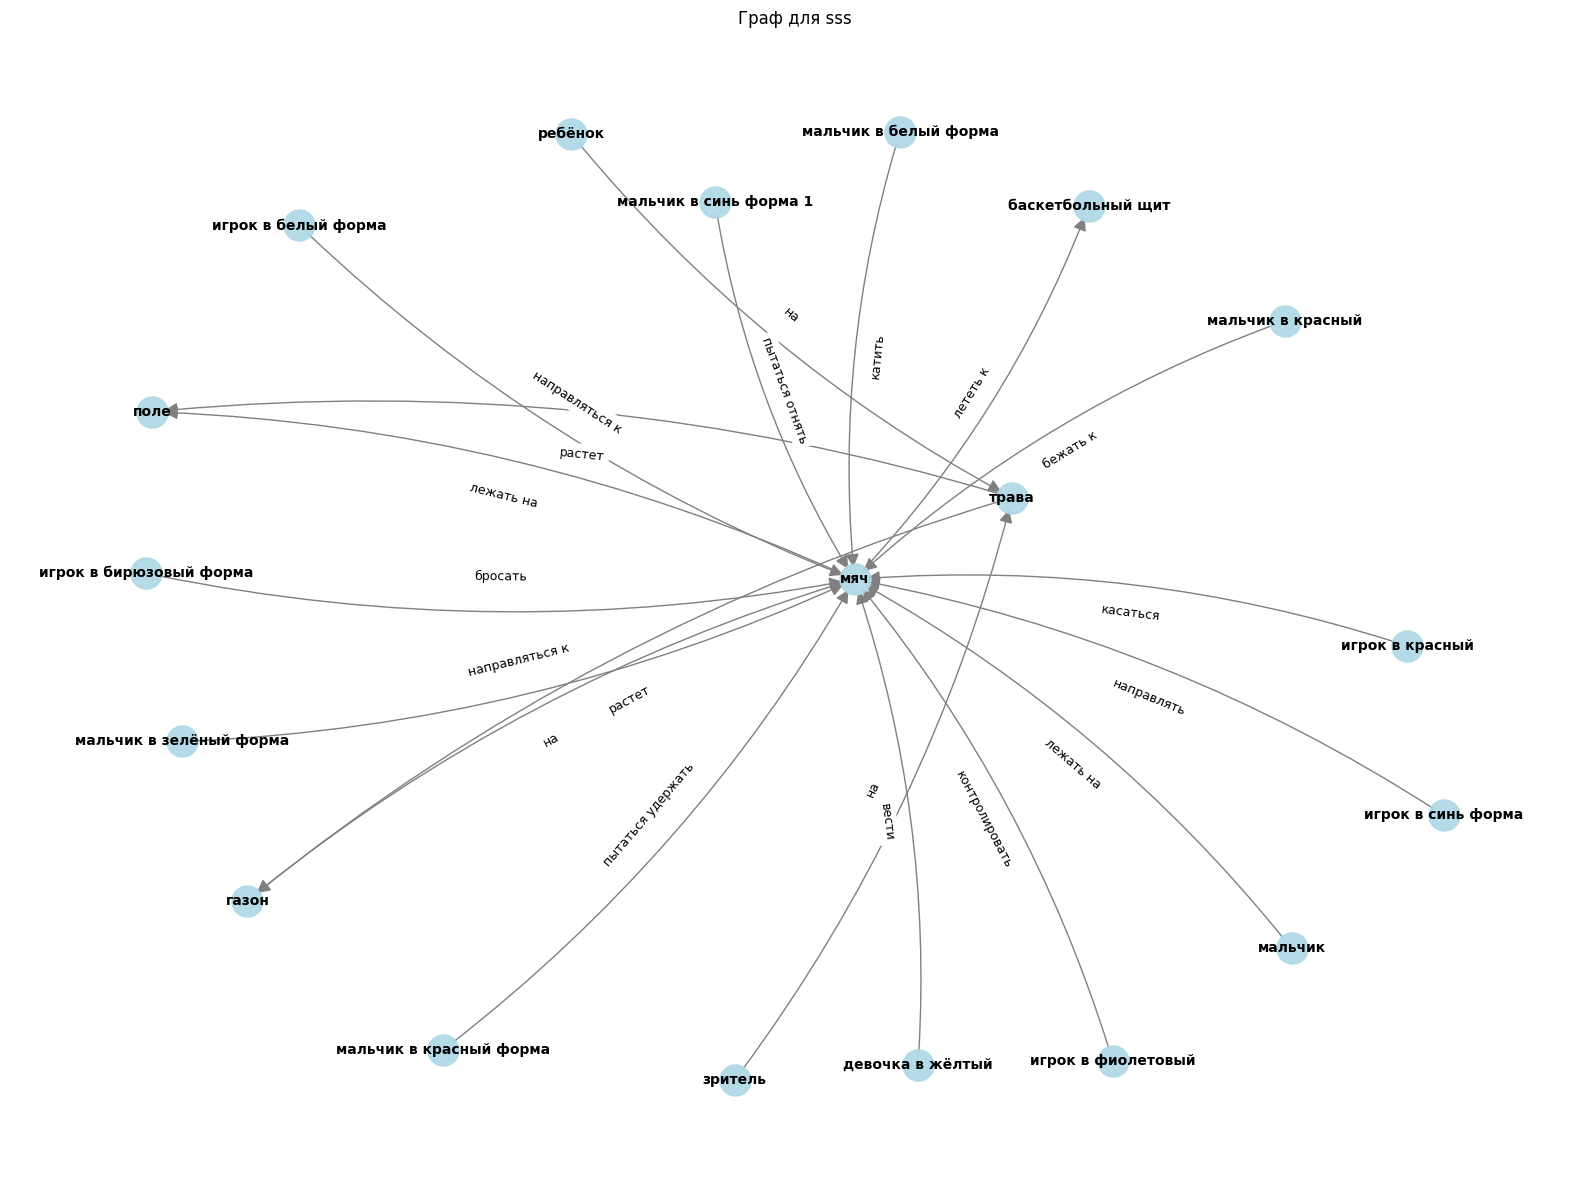

In [108]:
if result != {}:
    triples = [item[0] for item in result["1"]]
    triples_rel = [item for item in db_rel.index.keys()]
    # print(triples_rel)
    triples.extend(triples_rel)
    build_and_show_graph("sss", triples)
else:
    print("No results")

In [109]:
raise

RuntimeError: No active exception to reraise

In [ ]:
result = {
    '1':[],
    '2':[],
    '3':[]
    }

for triple, img_name in db.index.items():
    score = 0
    # if triple[0] == pattern[0]:
    if pattern[0] in triple[0]:
        score+=1

    # if triple[1] == pattern[1]:
    if pattern[1] in triple[1]:
        score+=1

    # if triple[2] == pattern[2]:
    if pattern[2] in triple[2]:
        score+=1
    
    if score>0:
        result[str(score)].append((triple, img_name))